In [80]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

In [81]:
df= pd.read_csv('student-scores.csv')


In [82]:
score_means = df[
    [
    "math_score",
    "history_score",
    "physics_score",
    "chemistry_score",
    "biology_score",
    "english_score",
    "geography_score"
    ]
].mean()

print(score_means)

math_score         83.4520
history_score      80.3320
physics_score      81.3365
chemistry_score    79.9950
biology_score      79.5815
english_score      81.2775
geography_score    80.8880
dtype: float64


In [83]:
df.mean(numeric_only=True)

id                            1000.5000
part_time_job                    0.1580
absence_days                     3.6655
extracurricular_activities       0.2040
weekly_self_study_hours         17.7555
math_score                      83.4520
history_score                   80.3320
physics_score                   81.3365
chemistry_score                 79.9950
biology_score                   79.5815
english_score                   81.2775
geography_score                 80.8880
dtype: float64

In [84]:
means = {}

for col in df.columns:
    if "score" in col:
        means[col] = df[col].mean()

print(means)

{'math_score': 83.452, 'history_score': 80.332, 'physics_score': 81.3365, 'chemistry_score': 79.995, 'biology_score': 79.5815, 'english_score': 81.2775, 'geography_score': 80.888}


In [85]:
print(df.head())

print("\nShape:")
print(df.shape)

print("\nInfo:")
print(df.info())

print("\nStatistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nMean of Score Columns:")
print(df.filter(like="score").mean())

   id first_name last_name                                  email  gender  \
0   1       Paul     Casey         paul.casey.1@gslingacademy.com    male   
1   2   Danielle  Sandoval  danielle.sandoval.2@gslingacademy.com  female   
2   3       Tina   Andrews       tina.andrews.3@gslingacademy.com  female   
3   4       Tara     Clark         tara.clark.4@gslingacademy.com  female   
4   5    Anthony    Campos     anthony.campos.5@gslingacademy.com    male   

   part_time_job  absence_days  extracurricular_activities  \
0          False             3                       False   
1          False             2                       False   
2          False             9                        True   
3          False             5                       False   
4          False             5                       False   

   weekly_self_study_hours   career_aspiration  math_score  history_score  \
0                       27              Lawyer          73             81   
1         

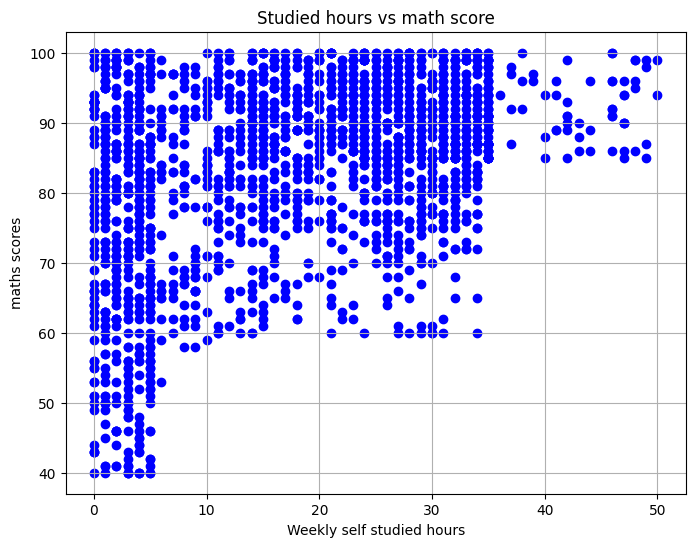

In [86]:
plt.figure(figsize=(8,6))

plt.scatter(df["weekly_self_study_hours"],
            df["math_score"],
            color = 'blue')

plt.xlabel("Weekly self studied hours")
plt.ylabel("maths scores")
plt.title("Studied hours vs math score")
plt.grid(True)
plt.show()

In [87]:
X = df[["weekly_self_study_hours"]]

y = df["math_score"]



In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [89]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [90]:
print("\nSlope Coefficient : ")
print(model.coef_[0])

print("\n Intercept : ")
print(model.intercept_)




Slope Coefficient : 
0.430662495531125

 Intercept : 
75.67235954861998


In [91]:
y_pred = model.predict(X_test)
print("\nPredictions : ")
print(y_pred)


Predictions : 
[83.85494696 76.10302204 82.56295948 77.82567203 76.53368454 77.82567203
 82.13229698 89.45355941 76.53368454 77.39500953 84.71627195 77.82567203
 77.82567203 90.3148844  84.71627195 82.13229698 76.10302204 86.86958443
 88.16157192 85.14693445 85.14693445 83.42428447 84.71627195 90.3148844
 87.30024693 77.82567203 92.03753438 77.82567203 85.14693445 83.85494696
 81.70163449 81.70163449 88.59223441 76.10302204 82.56295948 81.27097199
 77.82567203 81.27097199 87.73090942 90.74554689 79.54832201 89.45355941
 87.73090942 86.86958443 86.43892194 81.70163449 87.30024693 82.13229698
 82.13229698 86.00825944 76.96434704 86.43892194 77.39500953 77.39500953
 87.30024693 87.73090942 86.86958443 76.53368454 79.11765951 88.59223441
 80.409647   76.96434704 76.10302204 87.73090942 79.11765951 80.409647
 77.82567203 80.84030949 76.53368454 76.10302204 86.00825944 76.96434704
 90.3148844  87.73090942 81.27097199 77.39500953 97.20548433 76.10302204
 76.53368454 86.43892194 85.14693445 7

In [92]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nMAE : ", mae)
print("MSE : ", mse)
print("R2 : ", r2)
print("RMSE : ",rmse)


MAE :  9.498238611735836
MSE :  139.04097573746876
R2 :  0.16212713007562618
RMSE :  11.791563752847575


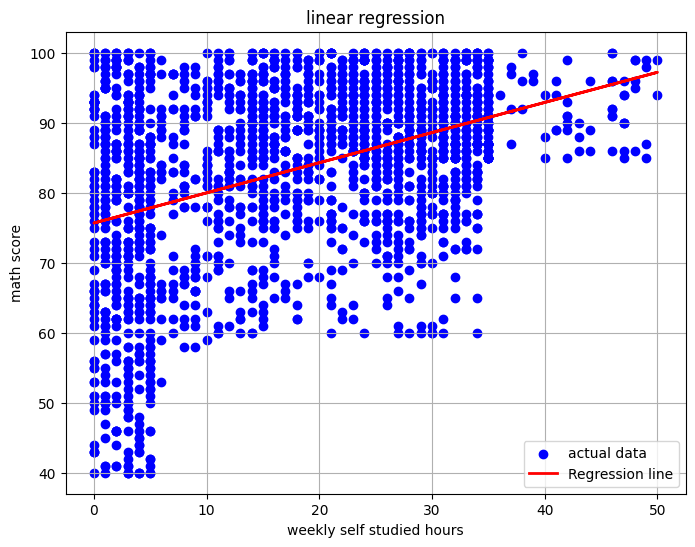

In [93]:
#regression line
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', label='actual data')
plt.plot(X,
        model.predict(X),
        color= "red",
        linewidth = 2,
        label = "Regression line")

plt.xlabel("weekly self studied hours")
plt.ylabel("math score")
plt.title("linear regression")
plt.grid(True)
plt.legend()
plt.show()

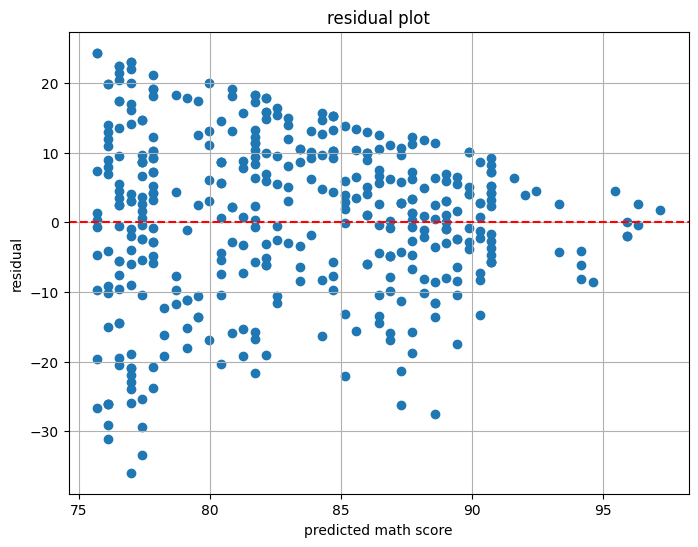

In [94]:
residual = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residual)
plt.axhline(y=0,
            color="red",
            linestyle="--")

plt.xlabel("predicted math score")
plt.ylabel("residual")
plt.title("residual plot")
plt.grid(True)
plt.show()

In [96]:
hours = [[25]]

prediction = model.predict(hours)

print("\nPredicted Math Score for 25 Study Hours:")
print(prediction)


Predicted Math Score for 25 Study Hours:
[86.43892194]


c:\Users\garim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
